### **MODELADO ESTADÍSTICO (REGRESIÓN LOGÍSTICA)**

### **1. Importacion de librerías.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import chi2

sns.set_style("whitegrid")

### **2. Carga e importación de datos.**

In [2]:
# Cargar las tres submuestras
muestras = {}
for i in range(1, 4):
    archivo = f"submuestra{i}.csv"
    df = pd.read_csv(archivo)
    muestras[f"submuestra{i}"] = df

# Dataframe combinado
df_total = pd.concat(
    [df.assign(subconjunto=f"Submuestra {i}") for i, (_, df) in enumerate(muestras.items(), start=1)],
    ignore_index=True
)

# Variable binaria para smartphone (1=Sí, 0=No)
df_total['smart'] = df_total['P8_4_2'].map({1: 1, 2: 0})

# Crear variable categórica de sexo (por si se necesita)
df_total['sexo_cat'] = df_total['SEXO'].map({1: 'Hombre', 2: 'Mujer'})

# Vista previa
print(f"Total de registros: {len(df_total)}")
print(df_total[['EDAD', 'SEXO', 'P8_4_2', 'smart']].head())

Total de registros: 300
   EDAD  SEXO  P8_4_2  smart
0    69     2     1.0      1
1    61     2     1.0      1
2    45     2     1.0      1
3    70     2     1.0      1
4    18     2     1.0      1


### **3 Modelo base: edad + sexo (sin interacción)**

In [3]:
# Seleccion de columnas a estudiar
X = df_total[['EDAD', 'SEXO']]

# Agrega una base matemática necesaria para que el modelo calcule correctamente.
X = sm.add_constant(X)

# Eligir si tiene o no smartphone
y = df_total['smart']

# Obtener el modelo de regresion logistica sin indicar el proceso
modelo_base = sm.Logit(y, X).fit(disp=False)

# Impresion resultados estadísticos del modelo.
print(modelo_base.summary())


                           Logit Regression Results                           
Dep. Variable:                  smart   No. Observations:                  300
Model:                          Logit   Df Residuals:                      297
Method:                           MLE   Df Model:                            2
Date:                Fri, 19 Jun 2026   Pseudo R-squ.:                  0.1316
Time:                        17:33:49   Log-Likelihood:                -93.850
converged:                       True   LL-Null:                       -108.07
Covariance Type:            nonrobust   LLR p-value:                 6.679e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2636      0.808      5.278      0.000       2.680       5.847
EDAD          -0.0517      0.010     -4.972      0.000      -0.072      -0.031
SEXO           0.0155      0.385      0.040      0.9

### **4. Interpretación de coeficientes y odds ratios**

In [4]:
# Obtener coefientes de la regresion logistica
coef = modelo_base.params

# Convierte los coeficientes matemáticos en Odds Ratios (OR) para poder entenderlos fácilmente.
odds_ratios = np.exp(coef)

# Calcula los márgenes de error mínimo y máximo (Intervalos de Confianza) para esos OR.
ic_odds = np.exp(modelo_base.conf_int())

# Renombra las columnas del margen de error para que se lea claro en el reporte.
ic_odds.columns = ['OR inf 95%', 'OR sup 95%']

# Muestra en la pantalla los resultados numéricos del modelo (Coeficientes, OR y márgenes de error).
print("Coeficientes (log-odds):")
print(coef)
print("\nOdds Ratios:")
print(odds_ratios)
print("\nIntervalos de confianza para los OR:")
print(ic_odds)

# Muestra en la pantalla la traducción del modelo a texto, explicando el impacto real de la EDAD y el SEXO.
print("\n--- Interpretación ---")
print("Constante (intercepto): log-odds de usar smartphone cuando EDAD=0 y SEXO=0 (sin sentido práctico).")
print(f"EDAD: por cada año adicional de edad, el log-odds de usar smartphone cambia en {coef['EDAD']:.3f}.")
print(f"      OR = {odds_ratios['EDAD']:.3f} -> la probabilidad de tener smartphone se multiplica por {odds_ratios['EDAD']:.3f} por cada año.")
print(f"SEXO (ref=1 hombre): el log-odds para mujeres difiere en {coef['SEXO']:.3f} respecto a hombres.")
print(f"      OR = {odds_ratios['SEXO']:.3f} -> las mujeres tienen {odds_ratios['SEXO']:.3f} veces más/menos probabilidad que los hombres.")


Coeficientes (log-odds):
const    4.263560
EDAD    -0.051722
SEXO     0.015512
dtype: float64

Odds Ratios:
const    71.062496
EDAD      0.949593
SEXO      1.015633
dtype: float64

Intervalos de confianza para los OR:
       OR inf 95%  OR sup 95%
const   14.588499  346.154763
EDAD     0.930429    0.969151
SEXO     0.477445    2.160481

--- Interpretación ---
Constante (intercepto): log-odds de usar smartphone cuando EDAD=0 y SEXO=0 (sin sentido práctico).
EDAD: por cada año adicional de edad, el log-odds de usar smartphone cambia en -0.052.
      OR = 0.950 -> la probabilidad de tener smartphone se multiplica por 0.950 por cada año.
SEXO (ref=1 hombre): el log-odds para mujeres difiere en 0.016 respecto a hombres.
      OR = 1.016 -> las mujeres tienen 1.016 veces más/menos probabilidad que los hombres.


### **5. Modelo con interacción (edad * sexo)**

In [6]:
# Crear término de interacción
df_total['EDAD_SEXO'] = df_total['EDAD'] * df_total['SEXO']

# Crea las variables y la constante para la regresion
X_int = df_total[['EDAD', 'SEXO', 'EDAD_SEXO']]
X_int = sm.add_constant(X_int)

# Crea el modelo sin mostrar el proceso e imprime sus metricas
modelo_int = sm.Logit(y, X_int).fit(disp=False)
print(modelo_int.summary())

                           Logit Regression Results                           
Dep. Variable:                  smart   No. Observations:                  300
Model:                          Logit   Df Residuals:                      296
Method:                           MLE   Df Model:                            3
Date:                Fri, 19 Jun 2026   Pseudo R-squ.:                  0.1321
Time:                        17:33:58   Log-Likelihood:                -93.792
converged:                       True   LL-Null:                       -108.07
Covariance Type:            nonrobust   LLR p-value:                 2.779e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8227      1.859      2.594      0.009       1.179       8.466
EDAD          -0.0629      0.035     -1.807      0.071      -0.131       0.005
SEXO          -0.3414      1.122     -0.304      0.7

### **6. Comparación de modelos: razón de verosimilitud**

In [7]:
# Diferencia de devianzas -> chi²
lr_stat = 2 * (modelo_int.llf - modelo_base.llf)
p_lr = chi2.sf(lr_stat, df=1)  # 1 grado de libertad adicional
print(f"Prueba de razón de verosimilitud (interacción añadida):")
print(f"  Δ deviance = {lr_stat:.3f}, p = {p_lr:.4f}")
if p_lr < 0.05:
    print("  La interacción mejora significativamente el modelo.")
else:
    print("  La interacción no aporta significativamente.")

Prueba de razón de verosimilitud (interacción añadida):
  Δ deviance = 0.115, p = 0.7340
  La interacción no aporta significativamente.


### **Evaluación del poder explicativo**

In [8]:
# Pseudo R² de McFadden
def pseudo_r2_mcfadden(modelo):
    return 1 - (modelo.llf / modelo.llnull)

r2_base = pseudo_r2_mcfadden(modelo_base)
r2_int = pseudo_r2_mcfadden(modelo_int)

print(f"McFadden R² (modelo base): {r2_base:.3f}")
print(f"McFadden R² (modelo con interacción): {r2_int:.3f}")

# AUC – ROC (usando sklearn)
y_pred_base = modelo_base.predict(X)
y_pred_int = modelo_int.predict(X_int)
auc_base = roc_auc_score(y, y_pred_base)
auc_int = roc_auc_score(y, y_pred_int)

print(f"\nAUC-ROC (modelo base): {auc_base:.3f}")
print(f"AUC-ROC (modelo con interacción): {auc_int:.3f}")

McFadden R² (modelo base): 0.132
McFadden R² (modelo con interacción): 0.132

AUC-ROC (modelo base): 0.769
AUC-ROC (modelo con interacción): 0.770


### **8 Curva ROC**

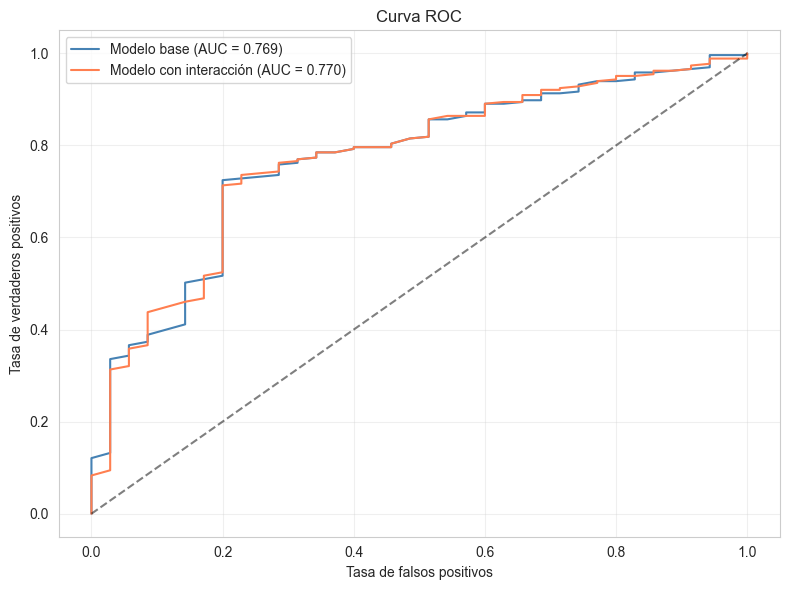

In [9]:
fpr_base, tpr_base, _ = roc_curve(y, y_pred_base)
fpr_int, tpr_int, _ = roc_curve(y, y_pred_int)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Modelo base (AUC = {auc_base:.3f})', color='steelblue')
plt.plot(fpr_int, tpr_int, label=f'Modelo con interacción (AUC = {auc_int:.3f})', color='coral')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **VALIDACIÓN DEL MODELO**

### **1. Multicolinealidad (VIF)**

In [10]:
# Solo para el modelo base (sin interacción)
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("Factores de inflación de varianza (VIF):")
print(vif_data)
print("(VIF < 10 indica ausencia de multicolinealidad grave)")

Factores de inflación de varianza (VIF):
  Variable        VIF
0    const  14.545573
1     EDAD   1.000291
2     SEXO   1.000291
(VIF < 10 indica ausencia de multicolinealidad grave)


### **2 Prueba de Hosmer-Lemeshow (calibración)**

In [11]:
def hosmer_lemeshow(y, y_pred, g=10):
    # Agrupar en deciles de probabilidad estimada
    df_eval = pd.DataFrame({'obs': y, 'pred': y_pred})
    df_eval['decile'] = pd.qcut(df_eval['pred'], q=g, duplicates='drop')
    
    observed = df_eval.groupby('decile')['obs'].sum()
    expected = df_eval.groupby('decile')['pred'].sum()
    n_g = df_eval.groupby('decile').size()
    # Estadístico HL
    hl_stat = np.sum((observed - expected)**2 / (expected * (1 - expected/n_g)))
    df_groups = len(observed) - 2
    p_hl = chi2.sf(hl_stat, df_groups)
    return hl_stat, p_hl

hl_base, p_hl_base = hosmer_lemeshow(y, y_pred_base)
hl_int, p_hl_int = hosmer_lemeshow(y, y_pred_int)

print("Prueba de Hosmer-Lemeshow:")
print(f"  Modelo base: χ²={hl_base:.3f}, g.l.≈{8}, p={p_hl_base:.4f}")
print(f"  Modelo interacción: χ²={hl_int:.3f}, g.l.≈{8}, p={p_hl_int:.4f}")
print("  (p>0.05 indica buena calibración)")

Prueba de Hosmer-Lemeshow:
  Modelo base: χ²=13.356, g.l.≈8, p=0.1002
  Modelo interacción: χ²=10.465, g.l.≈8, p=0.2339
  (p>0.05 indica buena calibración)


C:\Users\Dell\AppData\Local\Temp\ipykernel_21724\2865829071.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observed = df_eval.groupby('decile')['obs'].sum()
C:\Users\Dell\AppData\Local\Temp\ipykernel_21724\2865829071.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expected = df_eval.groupby('decile')['pred'].sum()
C:\Users\Dell\AppData\Local\Temp\ipykernel_21724\2865829071.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

### **3. Resumen de diagnóstico y selección del modelo final**

In [12]:
# Elegimos el modelo con interacción si la prueba LR fue significativa y el AUC mejora.
modelo_final = modelo_int if p_lr < 0.05 else modelo_base
print("Modelo final seleccionado:", "con interacción" if p_lr < 0.05 else "base")
print(modelo_final.summary())

Modelo final seleccionado: base
                           Logit Regression Results                           
Dep. Variable:                  smart   No. Observations:                  300
Model:                          Logit   Df Residuals:                      297
Method:                           MLE   Df Model:                            2
Date:                Fri, 19 Jun 2026   Pseudo R-squ.:                  0.1316
Time:                        17:34:22   Log-Likelihood:                -93.850
converged:                       True   LL-Null:                       -108.07
Covariance Type:            nonrobust   LLR p-value:                 6.679e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2636      0.808      5.278      0.000       2.680       5.847
EDAD          -0.0517      0.010     -4.972      0.000      -0.072      -0.031
SEXO           0.015